Practice 8

8. A new dataset, start to finish. Load sklearn.datasets.load_wine(as_frame=True), a 3-class dataset. Split with stratify, scale, fit all three models unchanged, and report test accuracy. Notice nothing about the model-fitting code had to change for 3 classes instead of 2. Plot the three models' test accuracy as a bar chart.

Cell 1

In [14]:
# Import all required libraries before starting.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

Cell 2

In [15]:
# Load the dataset and inspect it.

data = load_wine(as_frame=True)

df = data.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Cell 3

In [16]:
# Check dataset size and class distribution.

print(df.shape)

df["target"].value_counts()

(178, 14)


target
1    71
0    59
2    48
Name: count, dtype: int64

Cell 4

In [17]:
# Separate features from target labels.

X = df.drop(columns="target")

y = df["target"]

Cell 5

In [18]:
# Use stratified splitting for classification.

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

Cell 6

In [19]:
# Fit scaler on training data only.

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

Cell 7

In [20]:
# Logistic Regression learns coefficients from data.

logreg = LogisticRegression(max_iter=5000)

logreg.fit(X_train_scaled,y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

Cell 8

In [21]:
# KNN predicts using nearby samples.

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled,y_train)

y_pred_knn = knn.predict(X_test_scaled)

Cell 9

In [22]:
# Decision Trees learn rules through splits.

tree = DecisionTreeClassifier(max_depth=4, random_state=42)

tree.fit(X_train,y_train)

y_pred_tree = tree.predict(X_test)

Cell 10

In [23]:
# Accuracy measures the proportion of correct predictions.

acc_logreg = accuracy_score(y_test,y_pred_logreg)

acc_knn = accuracy_score(y_test,y_pred_knn)

acc_tree = accuracy_score(y_test,y_pred_tree)

Cell 11

In [24]:
# Compare model performance using the same metric.

print("Logistic Regression:", acc_logreg)

print("KNN:", acc_knn)

print("Decision Tree:", acc_tree)

Logistic Regression: 0.9722222222222222
KNN: 0.9722222222222222
Decision Tree: 0.9444444444444444


Cell 12

In [25]:
# Store results in a structured table.

results = pd.DataFrame({
    "Model": ["Logistic Regression","KNN","Decision Tree"],
    "Accuracy": [acc_logreg,acc_knn,acc_tree]})

results

,Model,Accuracy
0,Logistic Regression,0.972222
1,KNN,0.972222
2,Decision Tree,0.944444


Cell 13

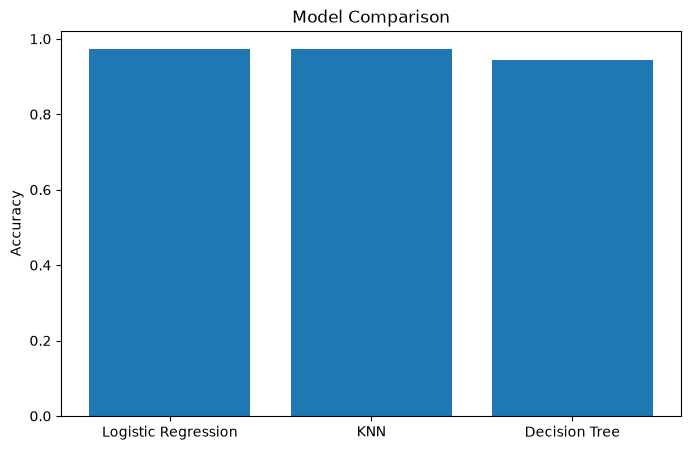

In [26]:
# Visualization makes model comparison easier.

plt.figure(figsize=(8, 5))

plt.bar(results["Model"],results["Accuracy"])

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()